In [82]:
import numpy as np
from matplotlib import pyplot as plt
import scipy.linalg as la
from tenpy.models.tf_ising import TFIChain
from tenpy.networks.mps import MPS
from tenpy.algorithms import dmrg, tebd
from tenpy.algorithms.exact_diag import get_full_wavefunction

In [83]:
L = 10                 
J = 1.0                 
g_i = 1.5               
g_f = 0.5               
t_final = 1.0           

# TEBD parameters
dt = 0.01
tebd_order = 4
chi_max = 4
svd_min = 1.e-12
# ============================================================
# 1. Initial Hamiltonian and DMRG ground state
# ============================================================

model_i = TFIChain({
    'L': L,
    'J': J,
    'g': g_i,
    'bc_MPS': 'finite',     # finite MPS = OBC
    'conserve': None,
})

# Start DMRG from a simple product state.
# "up" is an eigenstate of sigma_z.
psi = MPS.from_product_state(
    model_i.lat.mps_sites(),
    ['up'] * L,
    bc=model_i.lat.bc_MPS,
)

dmrg_params = {
    'mixer': True,
    'max_E_err': 1.e-12,
    'max_S_err': 1.e-10,
    'trunc_params': {
        'chi_max': chi_max,
        'svd_min': svd_min,
    },
}

print("Running DMRG...")
info = dmrg.run(psi, model_i, dmrg_params)

E_dmrg_initial = info['E']

print("\nInitial ground state")
print("--------------------")
print(f"g_i                 = {g_i}")
print(f"DMRG ground energy  = {E_dmrg_initial:.14f}")
print(f"max bond dimension  = {max(psi.chi)}")


# Make an independent copy of the DMRG ground state.
psi_tn = psi.copy()


/scratch/ashankar/Spin1LongRangeOrder.jl/python/.venv/lib/python3.13/site-packages/tenpy/networks/mps.py:1629: UserWarning: unit_cell_width is a new argument for MPS and similar classes. It is optional for now, but will become mandatory in a future release. The default value (unit_cell_width=len(sites)) is correct, iff the lattice is a Chain. For other lattices, it is incorrect. It is used for dipolar charges and correlation_function2.
  super().__init__(sites, bc, unit_cell_width)


Running DMRG...

Initial ground state
--------------------
g_i                 = 1.5
DMRG ground energy  = -16.53525440713386
max bond dimension  = 4


In [84]:
# ============================================================
# 4. Exact diagonalization
# ============================================================
# Pauli matrices
sx = np.array([[0., 1.],
               [1., 0.]], dtype=complex)
sz = np.array([[1., 0.],
               [0., -1.]], dtype=complex)
id2 = np.eye(2, dtype=complex)

def kron_all(operators):
    """Kronecker product of a list of matrices."""
    result = operators[0]

    for op in operators[1:]:
        result = np.kron(result, op)

    return result


def operator_on_site(op, site, L):
    """Put single-site operator 'op' on site 'site'."""
    operators = []

    for i in range(L):
        if i == site:
            operators.append(op)
        else:
            operators.append(id2)

    return kron_all(operators)


def ising_hamiltonian_ed(L, g, J=1.0):
    """
    Construct

        H = -J sum_i sx_i sx_{i+1}
            -g sum_i sz_i

    with open boundary conditions.
    """

    dim = 2**L
    H = np.zeros((dim, dim), dtype=complex)

    # Transverse-field terms
    for i in range(L):
        H += -g * operator_on_site(sz, i, L)

    # Ferromagnetic Ising terms
    for i in range(L - 1):

        operators = []

        for j in range(L):

            if j == i or j == i + 1:
                operators.append(sx)
            else:
                operators.append(id2)

        H += -J * kron_all(operators)

    return H


print("\nConstructing ED Hamiltonian...")

H_i_ed = ising_hamiltonian_ed(L, g_i, J)
H_f_ed = ising_hamiltonian_ed(L, g_f, J)



Constructing ED Hamiltonian...


In [85]:
def inf_dense_psis(psi1, psi2):
    overlap = np.vdot(psi1, psi2)
    fidelity = abs(overlap)**2
    infidelity = 1.0 - fidelity
    return infidelity
def inf_mps_dense(psi_mps, psi_dense):
    psi_dmrg_dense = get_full_wavefunction(psi_mps)
    psi_dmrg_dense /= np.linalg.norm(psi_dmrg_dense)
    return inf_dense_psis(psi_dmrg_dense, psi_dense)

In [86]:
# ============================================================
# 5. Exact initial ground state
# ============================================================

print("Diagonalizing initial Hamiltonian...")
E_i_ed, V_i_ed = la.eigh(H_i_ed)
E0_ed = E_i_ed[0]
psi0_ed = V_i_ed[:, 0]

print("\nInitial-state comparison")
print("-------------------------")
print(f"ED ground energy     = {E0_ed:.14f}")
print(f"DMRG ground energy   = {E_dmrg_initial:.14f}")
print(f"energy difference    = "
      f"{abs(E0_ed - E_dmrg_initial):.3e}")


Diagonalizing initial Hamiltonian...

Initial-state comparison
-------------------------
ED ground energy     = -16.53525494675915
DMRG ground energy   = -16.53525440713386
energy difference    = 5.396e-07


In [87]:
# ============================================================
# 2. Construct the post-quench Hamiltonian
# ============================================================

model_f = TFIChain({
    'L': L,
    'J': J,
    'g': g_f,
    'bc_MPS': 'finite',
    'conserve': None,
})


psi_tn = psi.copy() #reset psi_dmrg
psi_ed_t = psi0_ed
t_plot_step = 0.05
tgrid = np.arange(0, t_final+1e-9, t_plot_step)
inf_list = []
ent_list = []
inf_list.append(inf_mps_dense(psi_tn, psi0_ed))
ent_list.append(psi_tn.entanglement_entropy())
for t_f_step in tgrid[1:]: 
    N_steps = int(round(t_plot_step / dt))
    assert np.isclose(N_steps * dt, t_plot_step)

    tebd_params = {
        'N_steps': N_steps,
        'dt': dt,
        'order': tebd_order,
        'trunc_params': {
            'chi_max': chi_max,
            'svd_min': svd_min,
        },
    }

    # print("\nRunning TEBD...")
    eng = tebd.TEBDEngine(psi_tn, model_f, tebd_params)
    eng.run()
    psi_tn.canonical_form()
    ee = psi_tn.entanglement_entropy()
    ent_list.append(ee)

    # print("\nExact time evolution...")
    U_exact = la.expm(-1j * H_f_ed * t_plot_step)
    psi_ed_t = U_exact @ psi_ed_t
    psi_ed_t /= np.linalg.norm(psi_ed_t)
    inf = inf_mps_dense(psi_tn, psi_ed_t)
    inf_list.append(inf)
    print(f"final time = {t_f_step}, inf = {inf}")

print("TEBD finished.")
print(f"final bond dimension = {max(psi_tn.chi)}")


final time = 0.05, inf = 1.1434431257395516e-07
final time = 0.1, inf = 1.4488212995988903e-07
final time = 0.15000000000000002, inf = 1.590024035769133e-07
final time = 0.2, inf = 1.61336561332881e-07
final time = 0.25, inf = 1.6275785719166436e-07
final time = 0.30000000000000004, inf = 1.751563903917841e-07
final time = 0.35000000000000003, inf = 2.1477358602695062e-07
final time = 0.4, inf = 3.102632840645825e-07
final time = 0.45, inf = 5.154058970724407e-07
final time = 0.5, inf = 9.192167796934214e-07
final time = 0.55, inf = 1.6321261588903013e-06
final time = 0.6000000000000001, inf = 2.7254552305011615e-06
final time = 0.65, inf = 4.145193122528923e-06
final time = 0.7000000000000001, inf = 5.686135979177109e-06
final time = 0.75, inf = 7.08338860155866e-06
final time = 0.8, inf = 8.146406408671147e-06
final time = 0.8500000000000001, inf = 8.82020908710146e-06
final time = 0.9, inf = 9.159130825553419e-06
final time = 0.9500000000000001, inf = 9.27203902745255e-06
final time

Text(0.5, 0, 't')

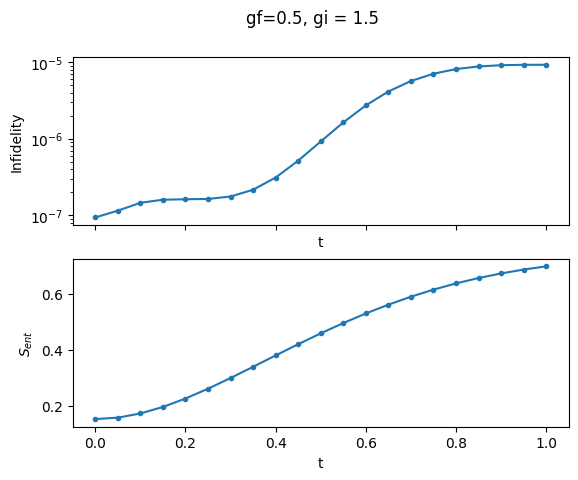

In [93]:
fig, ax = plt.subplots(2, sharex=True)
plot_ent = [ent[len(ent)//2] for ent in ent_list]
fig.suptitle(f"gf={g_f}, gi = {g_i}")
ax[0].plot(tgrid, inf_list, marker='.')
ax[0].set_yscale('log')
ax[0].set_ylabel('Infidelity')
ax[0].set_xlabel('t')
ax[1].plot(tgrid, plot_ent, marker='.')
ax[1].set_ylabel(r'$S_{ent}$')
ax[1].set_xlabel('t')


In [ ]:
# ============================================================
# 8. State overlap and infidelity
# ============================================================
psi_dmrg_dense = get_full_wavefunction(psi_tn)
overlap = np.vdot(psi_ed_t, psi_dmrg_dense)
fidelity = abs(overlap)**2
infidelity = 1.0 - fidelity
print(f"L                   = {L}")
print(f"J                   = {J}")
print(f"g_i                 = {g_i}")
print(f"g_f                 = {g_f}")
print(f"t                   = {t_final}")
print(f"TEBD dt             = {dt}")
print(f"TEBD order          = {tebd_order}")
print(f"max chi             = {max(psi_tn.chi)}")

print("\nFinal-state comparison")
print("----------------------")
print(f"|<ED|DMRG>|         = {abs(overlap):.14f}")
print(f"Fidelity            = {fidelity:.14f}")
print(f"Infidelity          = {infidelity:.6e}")


# ============================================================
# 9. Compare energies at the final time
# ============================================================

E_final_ed = np.vdot(
    psi_ed_t,
    H_f_ed @ psi_ed_t
).real

E_final_dmrg = np.vdot(
    psi_dmrg_dense,
    H_f_ed @ psi_dmrg_dense
).real

print("\nFinal energy")
print("------------")
print(f"ED energy           = {E_final_ed:.14f}")
print(f"DMRG/TEBD energy    = {E_final_dmrg:.14f}")
print(f"energy difference   = "
      f"{abs(E_final_ed - E_final_dmrg):.6e}")


# ============================================================
# 10. Optional: compare magnetization
# ============================================================
Sz_total = np.zeros_like(H_f_ed)

for i in range(L):
    Sz_total += operator_on_site(sz, i, L)

mz_ed = np.vdot(
    psi_ed_t,
    Sz_total @ psi_ed_t
).real / L

mz_dmrg = np.vdot(
    psi_dmrg_dense,
    Sz_total @ psi_dmrg_dense
).real / L

print("\nFinal magnetization")
print("-------------------")
print(f"<sigma_z>/L ED     = {mz_ed:.14f}")
print(f"<sigma_z>/L DMRG   = {mz_dmrg:.14f}")


L                   = 10
J                   = 1.0
g_i                 = 1.5
g_f                 = 0.5
t                   = 1.0
TEBD dt             = 0.01
TEBD order          = 4
max chi             = 4

Final-state comparison
----------------------
|<ED|DMRG>|         = 0.99999535844905
Fidelity            = 0.99999071691965
Infidelity          = 9.283080e-06

Final energy
------------
ED energy           = -7.60990863644864
DMRG/TEBD energy    = -7.60990666524836
energy difference   = 1.971200e-06

Final magnetization
-------------------
<sigma_z>/L ED     = 0.27612340044231
<sigma_z>/L DMRG   = 0.27612535808848
